In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/sample_submission.csv
/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv
/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv


**Importing all the modules**

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

**Initialized the dataset**

In [3]:
train_df=pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv')

**Shape of the dataset**

In [4]:
print(f"Train dataset shape: {train_df.shape}");
print(f"Test dataset shape: {test_df.shape}");

Train dataset shape: (7000, 6)
Test dataset shape: (1700, 5)


**Info about the Dataset**

In [5]:
print("Data Types of each column:")
print(train_df.info())
print("\nNumerical columns:", train_df.select_dtypes(include='number').columns.tolist())
print("Categorical columns:", train_df.select_dtypes(include='object').columns.tolist())

Data Types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7000 non-null   int64  
 1   phrase     7000 non-null   object 
 2   feature_1  6088 non-null   float64
 3   feature_2  5896 non-null   float64
 4   feature_3  5938 non-null   float64
 5   sentiment  7000 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 328.3+ KB
None

Numerical columns: ['id', 'feature_1', 'feature_2', 'feature_3', 'sentiment']
Categorical columns: ['phrase']


In [6]:
print(train_df.head())
print(train_df.columns)

   id                                             phrase  feature_1  \
0   0  It may as well be called `` Jar-Jar Binks : Th...       14.0   
1   1                               You have to see it .        6.0   
2   2  ... either you 're willing to go with this cla...       16.0   
3   3  Watching Harris ham it up while physically and...       37.0   
4   4  Pete 's screenplay manages to find that real n...       20.0   

   feature_2  feature_3  sentiment  
0        5.0        7.0          0  
1        1.0        NaN          2  
2        0.0        6.0          1  
3        NaN        3.0          1  
4        1.0        4.0          2  
Index(['id', 'phrase', 'feature_1', 'feature_2', 'feature_3', 'sentiment'], dtype='object')


**DESCRIPTIVE STATISTICS OF NUMERICAL COLUMNS**

In [7]:
num_cols = ['feature_1', 'feature_2', 'feature_3']

desc = train_df[num_cols].describe().T
desc['median'] = train_df[num_cols].median()
desc = desc[['count','min','max','mean','median','std','25%','75%']]
desc.columns = ['Count','Min','Max','Mean','Median','Std Dev','Q1 (25%)','Q3 (75%)']


print('DESCRIPTIVE STATISTICS OF NUMERICAL COLUMNS')

desc.round(4)

DESCRIPTIVE STATISTICS OF NUMERICAL COLUMNS


,Count,Min,Max,Mean,Median,Std Dev,Q1 (25%),Q3 (75%)
feature_1,6088.0,1.0,52.0,19.0256,18.0,9.3036,12.0,25.0
feature_2,5896.0,0.0,19.0,1.9966,1.0,1.6349,1.0,3.0
feature_3,5938.0,0.0,19.0,3.3341,3.0,2.3212,2.0,4.0


In [8]:
feature_columns = ['feature_1', 'feature_2', 'feature_3']
desc = train_df[feature_columns].describe()
print(desc)

         feature_1    feature_2    feature_3
count  6088.000000  5896.000000  5938.000000
mean     19.025624     1.996608     3.334119
std       9.303562     1.634858     2.321154
min       1.000000     0.000000     0.000000
25%      12.000000     1.000000     2.000000
50%      18.000000     1.000000     3.000000
75%      25.000000     3.000000     4.000000
max      52.000000    19.000000    19.000000


**Identifying and Handling Missing Values**

In [9]:
feature_columns = ['feature_1', 'feature_2', 'feature_3']

print("Missing values before imputation:\n", train_df.isnull().sum())

# Text Imputation
train_df['phrase'] = train_df['phrase'].fillna('')
test_df['phrase'] = test_df['phrase'].fillna('')

# Numerical Imputation (Median)
num_cols = ['feature_1', 'feature_2', 'feature_3']
imputer = SimpleImputer(strategy='median')

train_df[num_cols] = imputer.fit_transform(train_df[feature_columns])
test_df[num_cols] = imputer.transform(test_df[feature_columns])
    
print('\n')

print("Null values in train dataset :\n ",train_df.isnull().sum())
print('\n')
print("Null values in test dataset :\n",test_df.isnull().sum())

Missing values before imputation:
 id              0
phrase          0
feature_1     912
feature_2    1104
feature_3    1062
sentiment       0
dtype: int64


Null values in train dataset :
  id           0
phrase       0
feature_1    0
feature_2    0
feature_3    0
sentiment    0
dtype: int64


Null values in test dataset :
 id           0
phrase       0
feature_1    0
feature_2    0
feature_3    0
dtype: int64


**HANDLING DUPLICATES**

In [10]:
dup_count = train_df.duplicated(subset=['phrase', 'feature_1', 'feature_2', 'feature_3']).sum()
print(f'Duplicate rows found: {dup_count}')

if dup_count > 0:
    train_df = train_df.drop_duplicates(subset=['phrase', 'feature_1', 'feature_2', 'feature_3']).reset_index(drop=True)
    print(f'Duplicates dropped. New train shape: {train_df.shape}')
else:
    print('No duplicates — dataset is clean.')
print(f'Train shape after duplicate check: {train_df.shape}')

Duplicate rows found: 96
Duplicates dropped. New train shape: (6904, 6)
Train shape after duplicate check: (6904, 6)


**OUTLIER DETECTION**


Using the IQR method, outliers were detected in all three features (feature_1, feature_2, feature_3).


SINCE, These features likely represent linguistic properties of movie review phrases (e.g., word count, sentiment scores). Extreme values may correspond to unusually long or strongly-worded reviews, which carry meaningful signal. Additionally, the models used (Random Forest, XGBoost, GradientBoosting) are tree-based and robust to outliers by design.

In [11]:
#  Outlier Handling via IQR Clipping
for col in num_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    train_df[col] = np.clip(train_df[col], lower_bound, upper_bound)
    test_df[col] = np.clip(test_df[col], lower_bound, upper_bound)


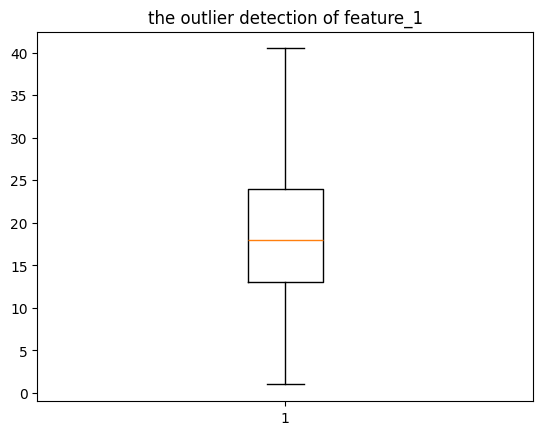

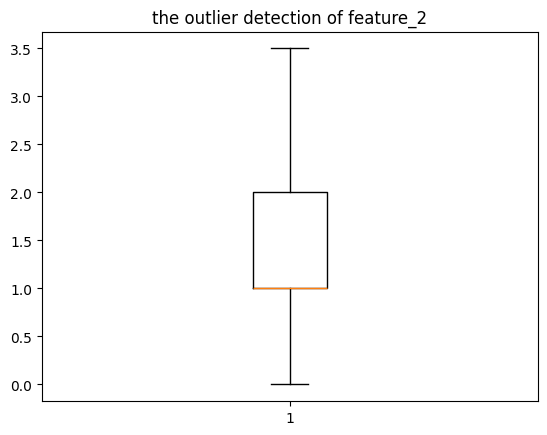

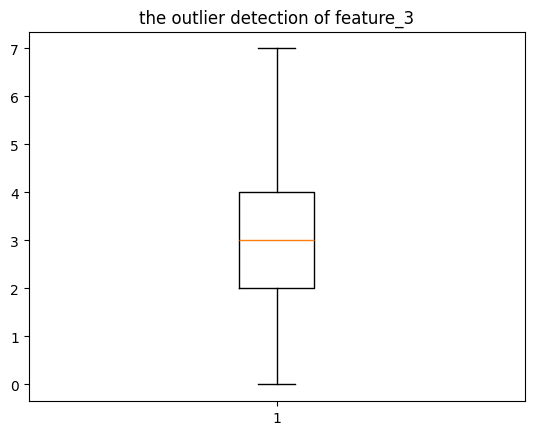

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in feature_columns:
    data = train_df[col]
    plt.boxplot(data)
    plt.title(f"the outlier detection of {col}")
    plt.show()

**VISUALIZATIONS**

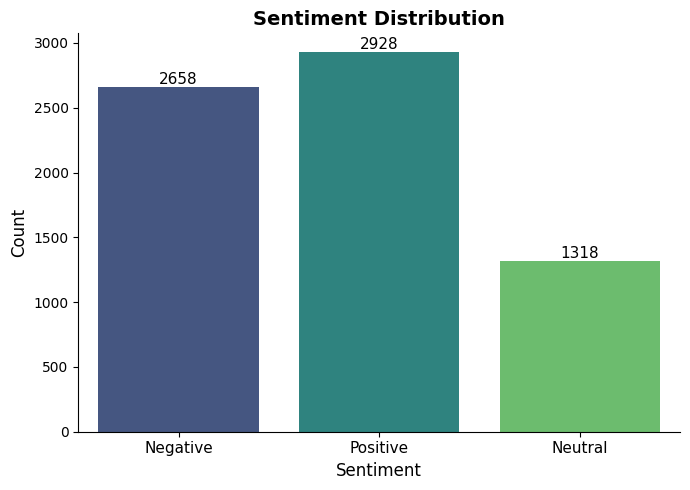

In [13]:
# Visualisaiton 1

import seaborn as sns
import matplotlib.pyplot as plt

sentiment_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
train_df['sentiment_label']=train_df['sentiment'].map(sentiment_map)


plt.figure(figsize=(7,5))

ax = sns.countplot(x='sentiment_label', hue='sentiment_label', data=train_df, palette='viridis', legend=False)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)


plt.title("Sentiment Distribution", fontsize=14, weight='bold')
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Count", fontsize=12)


plt.xticks(fontsize=11)
plt.yticks(fontsize=10)
sns.despine()

plt.tight_layout()
plt.show()

**VISUALISATION 2**

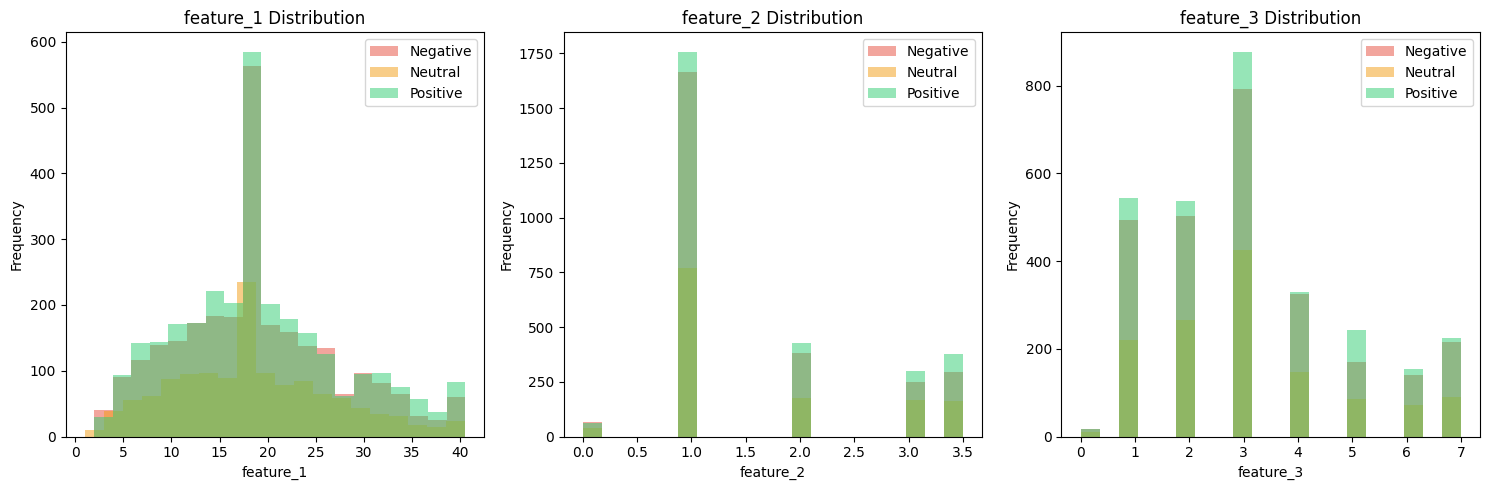

In [14]:
import matplotlib.pyplot as plt

labels = ['Negative', 'Neutral', 'Positive']
colors = ['#e74c3c', '#f39c12', '#2ecc71']

plt.figure(figsize=(15,5))

for i, col in enumerate(feature_columns):
    plt.subplot(1, len(feature_columns), i+1)
    
    for sent in [0, 1, 2]:
        data = train_df[train_df['sentiment'] == sent][col]
        plt.hist(data, bins=20, alpha=0.5, color=colors[sent], label=labels[sent])
    
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()

plt.tight_layout()
plt.show()

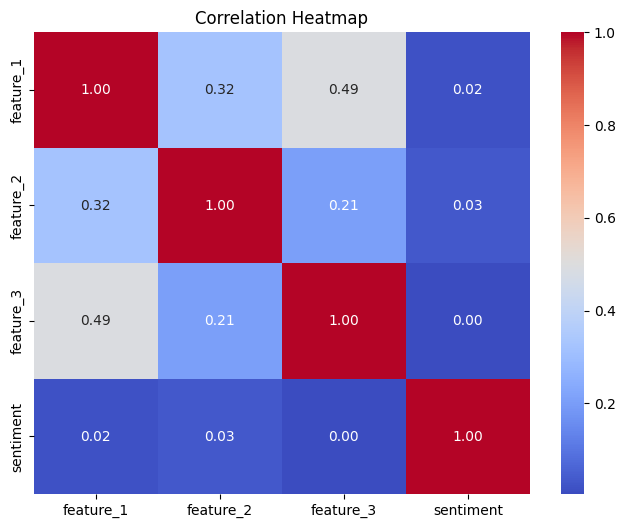

In [15]:
# visualisation 3 -- correlation heatmap
train_new=train_df.copy()
train_new=train_new.drop('id',axis=1)
corr = train_new.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

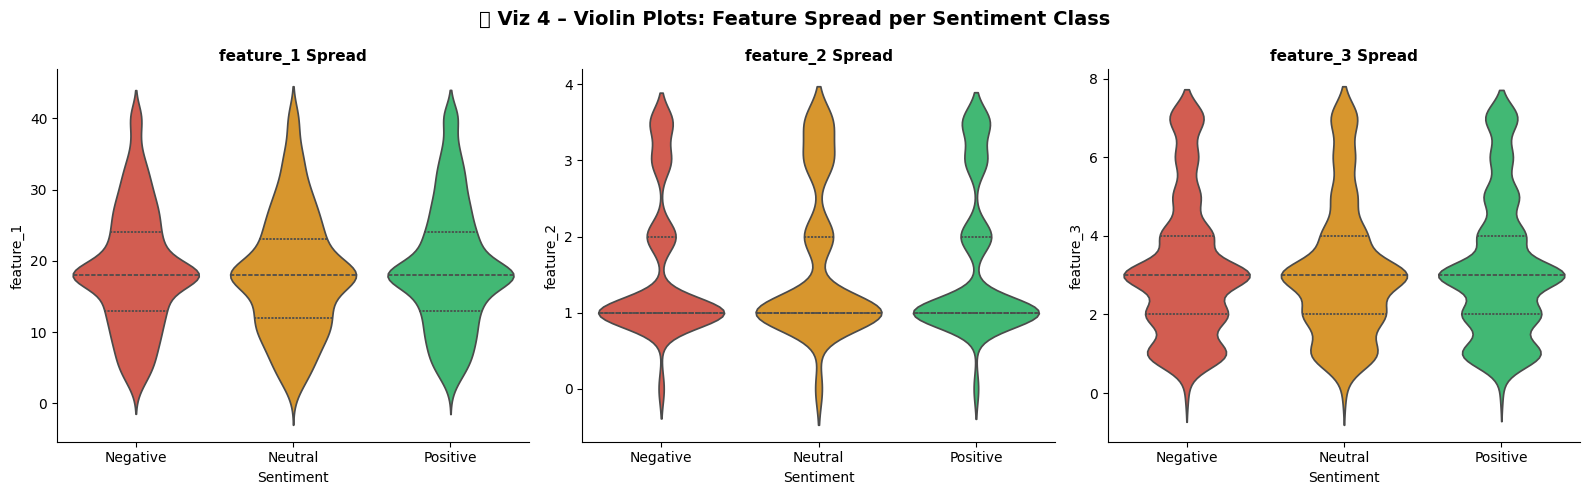


Insight: Violin plots reveal the median, IQR, and density shape per class.
Wide "violins" indicate high variance; narrow = concentrated values.


In [16]:
# Visualization 4 - Violin Plots

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, num_cols):
    sns.violinplot(x='sentiment_label', y=col, hue='sentiment_label',
                   data=train_df, order=['Negative','Neutral','Positive'],
                   palette={'Negative':'#E74C3C','Neutral':'#F39C12','Positive':'#2ECC71'},
                   inner='quartile', legend=False, ax=ax)
    ax.set_title(f'{col} Spread', fontsize=11, fontweight='bold')
    ax.set_xlabel('Sentiment')
    sns.despine(ax=ax)

plt.suptitle('📊 Viz 4 – Violin Plots: Feature Spread per Sentiment Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInsight: Violin plots reveal the median, IQR, and density shape per class.')
print('Wide "violins" indicate high variance; narrow = concentrated values.')

**FEATURE SCALING**

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp
# Scale Numerical Features
scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df[num_cols])
X_test_num = scaler.transform(test_df[num_cols])

# Encode Text Data using TF-IDF
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_train_text = tfidf.fit_transform(train_df['phrase'])
X_test_text = tfidf.transform(test_df['phrase'])

# Combine Scaled numerical features with TF-IDF encoded text features
X = sp.hstack([X_train_text, sp.csr_matrix(X_train_num)])
y = train_df['sentiment']

X_test_final = sp.hstack([X_test_text, sp.csr_matrix(X_test_num)])

# Split into train and validation sets
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVC': LinearSVC(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Ridge Classifier': RidgeClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, n_estimators=50, verbose=-1)
}

# Train and collect accuracies
base_results = {}
for name, model in models.items():
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    base_results[name] = acc
    print(f"{name} Validation Accuracy: {acc:.4f}")

Logistic Regression Validation Accuracy: 0.6300
Linear SVC Validation Accuracy: 0.5894
Random Forest Validation Accuracy: 0.5749
Decision Tree Validation Accuracy: 0.4642
Ridge Classifier Validation Accuracy: 0.6083
AdaBoost Validation Accuracy: 0.4330
LightGBM Validation Accuracy: 0.5431


**HYPER-PARAMETER TUNING ON 3 MODELS**

In [19]:
#  Tuning Logistic Regression
lr_params = {'C': [0.1, 1, 10]}
lr_tuned = RandomizedSearchCV(LogisticRegression(max_iter=1000), lr_params, cv=3, n_iter=3, random_state=42)
lr_tuned.fit(X_tr, y_tr)
print(f"Tuned Logistic Regression Acc: {accuracy_score(y_val, lr_tuned.predict(X_val)):.4f}")



#  Tuning LightGBM
lgb_params = {'learning_rate': [0.01, 0.1, 0.2], 'num_leaves': [15, 31, 50]}
lgb_tuned = RandomizedSearchCV(LGBMClassifier(verbose=-1, random_state=42), lgb_params, cv=3, n_iter=3, random_state=42)
lgb_tuned.fit(X_tr, y_tr)
print(f"Tuned LightGBM Acc: {accuracy_score(y_val, lgb_tuned.predict(X_val)):.4f}")



#  Tuning Random Forest
rf_params = {'max_depth': [None, 10, 20], 'n_estimators': [50, 100]}
rf_tuned = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, n_iter=3, random_state=42)
rf_tuned.fit(X_tr, y_tr)
print(f"Tuned Random Forest Acc: {accuracy_score(y_val, rf_tuned.predict(X_val)):.4f}")

Tuned Logistic Regression Acc: 0.6300
Tuned LightGBM Acc: 0.5250
Tuned Random Forest Acc: 0.5865


**model performance comparison**

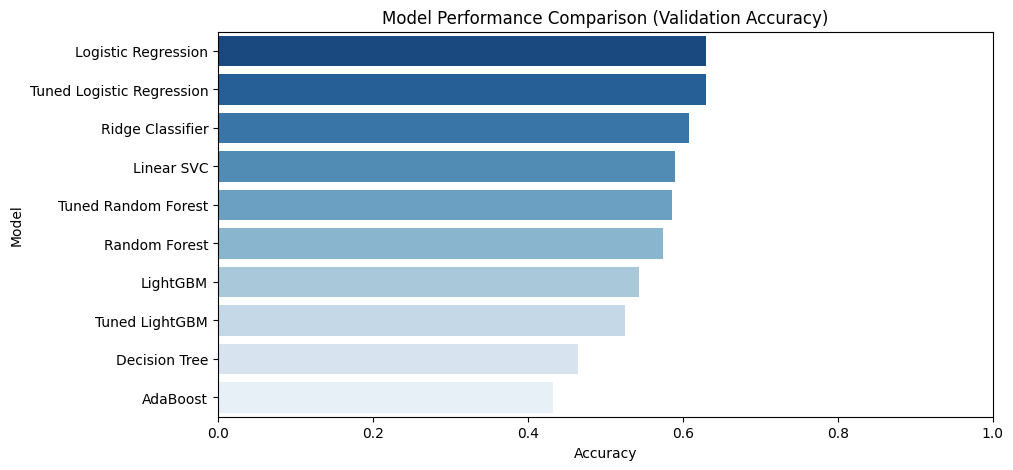

In [20]:
# Update results dict with tuned accuracies
base_results['Tuned Logistic Regression'] = accuracy_score(y_val, lr_tuned.predict(X_val))
base_results['Tuned LightGBM'] = accuracy_score(y_val, lgb_tuned.predict(X_val))
base_results['Tuned Random Forest'] = accuracy_score(y_val, rf_tuned.predict(X_val))

# Plot Comparison
plt.figure(figsize=(10, 5))
results_df = pd.DataFrame(list(base_results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)
sns.barplot(data=results_df, x='Accuracy', y='Model', palette='Blues_r')
plt.title("Model Performance Comparison (Validation Accuracy)")
plt.xlim(0, 1.0)
plt.show()

best_model = lr_tuned.best_estimator_ 


**Submission file**

In [21]:
best_model.fit(X, y) 
test_preds = best_model.predict(X_test_final)


submission = pd.DataFrame({
    'id': test_df['id'],          
    'sentiment': test_preds      
})
submission.to_csv('submission.csv', index=False)